In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

import os
import warnings
warnings.filterwarnings("ignore")

In [2]:
df = pd.read_csv("../data/processed/features_v2.csv")

df["date"] = pd.to_datetime(df["date"])
df = df.sort_values("date").reset_index(drop=True)

# Ensure season column exists
if "year" not in df.columns:
    df["year"] = df["date"].dt.year

print("Seasons available:", sorted(df["year"].unique()))

Seasons available: [1996, 1997, 1998, 1999, 2000, 2001, 2002, 2003, 2004, 2005, 2006, 2007, 2008, 2009, 2010, 2011, 2012, 2013, 2014, 2015, 2016, 2017, 2018, 2019, 2020, 2021, 2022, 2023, 2024]


In [3]:
targets = {
    "FinishPosition": "positionOrder",
    "AvgLapTime": "avgLapTime_s",
    "ConstructorPoints": "points"
}

In [4]:
drop_cols = [
    "raceId",
    "driverId",
    "constructorId",
    "date"
]

features = [
    col for col in df.columns
    if col not in drop_cols + ["positionOrder", "avgLapTime_s", "points"]
]

print("Number of features:", len(features))

Number of features: 13


In [5]:
def run_season_cv(target_name, target_column):
    
    seasons = sorted(df["year"].unique())
    season_results = []
    
    for season in seasons:
        
        train = df[df["year"] != season]
        test  = df[df["year"] == season]
        
        X_train = train[features]
        y_train = train[target_column]
        
        X_test = test[features]
        y_test = test[target_column]
        
        model = RandomForestRegressor(
            n_estimators=300,
            max_depth=10,
            random_state=42,
            n_jobs=-1
        )
        
        model.fit(X_train, y_train)
        preds = model.predict(X_test)
        
        mae = mean_absolute_error(y_test, preds)
        rmse = np.sqrt(mean_squared_error(y_test, preds))
        r2 = r2_score(y_test, preds)
        
        season_results.append([season, target_name, mae, rmse, r2])
        
        print(f"{target_name} - Season {season} completed")
    
    return season_results


In [6]:
all_results = []

for name, column in targets.items():
    print(f"\nRunning CV for {name}")
    results = run_season_cv(name, column)
    all_results.extend(results)



Running CV for FinishPosition
FinishPosition - Season 1996 completed
FinishPosition - Season 1997 completed
FinishPosition - Season 1998 completed
FinishPosition - Season 1999 completed
FinishPosition - Season 2000 completed
FinishPosition - Season 2001 completed
FinishPosition - Season 2002 completed
FinishPosition - Season 2003 completed
FinishPosition - Season 2004 completed
FinishPosition - Season 2005 completed
FinishPosition - Season 2006 completed
FinishPosition - Season 2007 completed
FinishPosition - Season 2008 completed
FinishPosition - Season 2009 completed
FinishPosition - Season 2010 completed
FinishPosition - Season 2011 completed
FinishPosition - Season 2012 completed
FinishPosition - Season 2013 completed
FinishPosition - Season 2014 completed
FinishPosition - Season 2015 completed
FinishPosition - Season 2016 completed
FinishPosition - Season 2017 completed
FinishPosition - Season 2018 completed
FinishPosition - Season 2019 completed
FinishPosition - Season 2020 comp

In [7]:
cv_results_df = pd.DataFrame(
    all_results,
    columns=["season", "target", "MAE", "RMSE", "R2"]
)

print("\nPer-Season CV Results:")
print(cv_results_df)



Per-Season CV Results:
    season             target       MAE      RMSE        R2
0     1996     FinishPosition  4.483172  5.175132  0.186741
1     1997     FinishPosition  4.659034  5.451957  0.201019
2     1998     FinishPosition  4.255591  5.092774  0.290260
3     1999     FinishPosition  4.518991  5.460265  0.175268
4     2000     FinishPosition  4.397636  5.288976  0.253502
..     ...                ...       ...       ...       ...
82    2020  ConstructorPoints  3.531623  5.199227  0.494976
83    2021  ConstructorPoints  3.049180  4.726886  0.570863
84    2022  ConstructorPoints  2.968276  4.532499  0.615944
85    2023  ConstructorPoints  2.876006  4.246311  0.662047
86    2024  ConstructorPoints  2.666666  4.219065  0.665609

[87 rows x 5 columns]


In [8]:
aggregate_results = (
    cv_results_df
    .groupby("target")[["MAE", "RMSE", "R2"]]
    .mean()
    .reset_index()
)

print("\nAverage CV Performance by Target:")
print(aggregate_results)



Average CV Performance by Target:
              target       MAE       RMSE        R2
0         AvgLapTime  9.876965  18.813654  0.027069
1  ConstructorPoints  2.193231   3.404108  0.501842
2     FinishPosition  3.663134   4.626459  0.385761


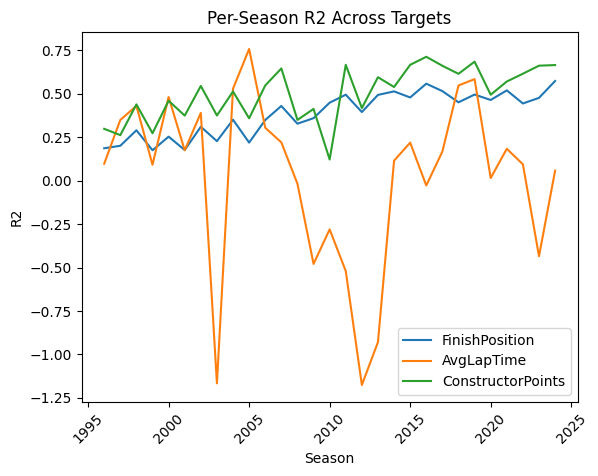

In [9]:
plt.figure()

for target_name in targets.keys():
    subset = cv_results_df[cv_results_df["target"] == target_name]
    plt.plot(subset["season"], subset["R2"], label=target_name)

plt.title("Per-Season R2 Across Targets")
plt.xlabel("Season")
plt.ylabel("R2")
plt.legend()
plt.xticks(rotation=45)
plt.show()


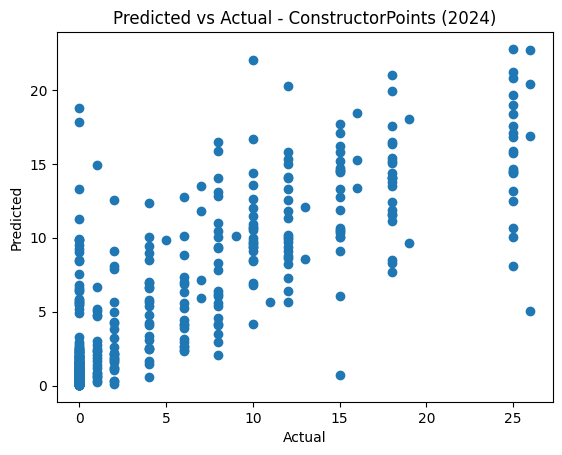

In [10]:
example_target = "ConstructorPoints"
example_column = targets[example_target]

last_season = sorted(df["year"].unique())[-1]

train = df[df["year"] != last_season]
test  = df[df["year"] == last_season]

X_train = train[features]
y_train = train[example_column]

X_test = test[features]
y_test = test[example_column]

model = RandomForestRegressor(
    n_estimators=300,
    max_depth=10,
    random_state=42,
    n_jobs=-1
)

model.fit(X_train, y_train)
preds = model.predict(X_test)

plt.figure()
plt.scatter(y_test, preds)
plt.xlabel("Actual")
plt.ylabel("Predicted")
plt.title(f"Predicted vs Actual - {example_target} ({last_season})")
plt.show()


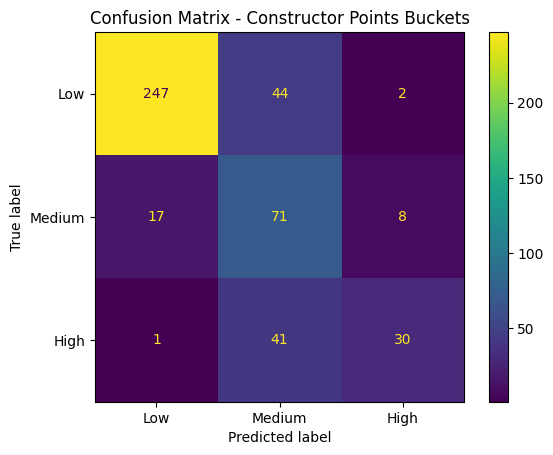

In [11]:
def bucket_points(x):
    if x >= 15:
        return "High"
    elif x >= 5:
        return "Medium"
    else:
        return "Low"

y_test_bucket = y_test.apply(bucket_points)
pred_bucket = pd.Series(preds).apply(bucket_points)

cm = confusion_matrix(
    y_test_bucket,
    pred_bucket,
    labels=["Low", "Medium", "High"]
)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["Low", "Medium", "High"]
)

disp.plot()
plt.title("Confusion Matrix - Constructor Points Buckets")
plt.show()


In [12]:
os.makedirs("../reports", exist_ok=True)

cv_results_df.to_csv("../reports/day10_season_cv_results.csv", index=False)
aggregate_results.to_csv("../reports/day10_aggregate_results.csv", index=False)

print("Day 10 results saved to /reports/")


Day 10 results saved to /reports/


The dataset spans seasons from 1996 to 2024. Earlier seasons were excluded during preprocessing due to incomplete lap time and pit stop records. The wide temporal coverage enables robust cross-season evaluation but introduces structural variability due to regulatory and scoring system changes over time.